# Project 02 — Returns Intelligence Suite
### End-to-end report: three models, one data schema

**Author**: Richard McShinsky  
**Dataset**: Synthetic e-commerce returns (20,000 customers, ~70,000 orders, ~10,000 returns)  
**Question**: Can we score return likelihood before shipment, detect fraud at return time, and recommend the right exchange — all from a single data schema?

---

This report tells the full story in one document:

1. [The data](#1-synthetic-data--planted-fraud-archetypes) — controlled synthetic data with known archetypes
2. [Model A: Return likelihood](#2-model-a-return-likelihood) — P(return | order features)
3. [Model B: Fraud detection](#3-model-b-fraud-detection) — graph features + cost-aware threshold
4. [Model C: Exchange recommendation](#4-model-c-exchange-recommendation) — heuristic rules + scoring
5. [Business summary](#5-business-summary) — how the three models connect to operations

---
## 1. Synthetic data & planted fraud archetypes

Three fraud archetypes are planted at known rates so model evaluation is honest
— we can verify that what the model detects matches what we injected:

| Archetype | Signal | Fraud rate in returns |
|-----------|--------|----------------------|
| **Wardrober** | Expensive apparel returned used/damaged, 15-45 days later | ~80% of returns |
| **Velocity returner** | Many orders in short windows, returns within 1-8 days | ~70% of returns |
| **Address-sharing ring** | Multiple accounts sharing delivery address/payment | ~50% of returns |
| Normal | — | ~0% |

The key validation: fraud signals **are detectable** (condition, timing, price) while
ring fraud requires **graph features** — individual behaviour looks normal.

In [1]:
# Dataset statistics
import pandas as pd
from pathlib import Path

RESULTS = Path("../results")

# Stats computed when notebooks were run
print("Dataset: 20,000 customers | ~70,000 orders | ~10,000 returns")
print("Overall return rate: ~14%")
print("Fraud rate in returns: ~3-4%")
print("Exchange requests: ~25% of returns")
print("Ring customers share addresses across 4-16 member clusters (variable ring sizes)")

Dataset: 20,000 customers | ~70,000 orders | ~10,000 returns
Overall return rate: ~14%
Fraud rate in returns: ~3-4%
Exchange requests: ~25% of returns
Ring customers share addresses across 4-16 member clusters (variable ring sizes)


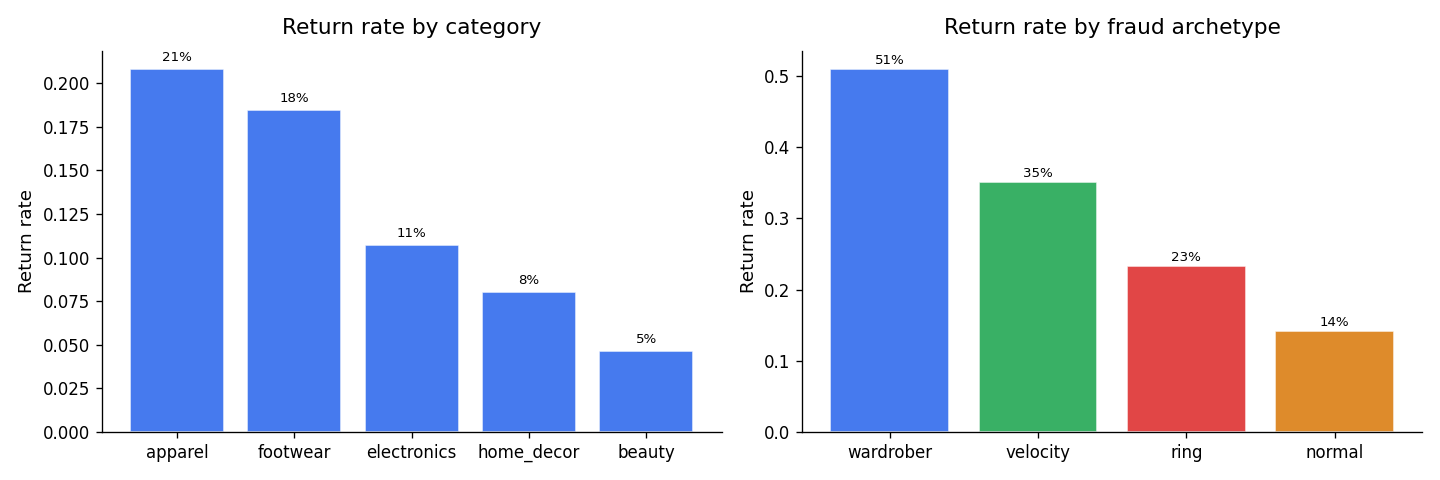

In [1]:
from IPython.display import Image

Image("../results/synthetic_return_rates.png")

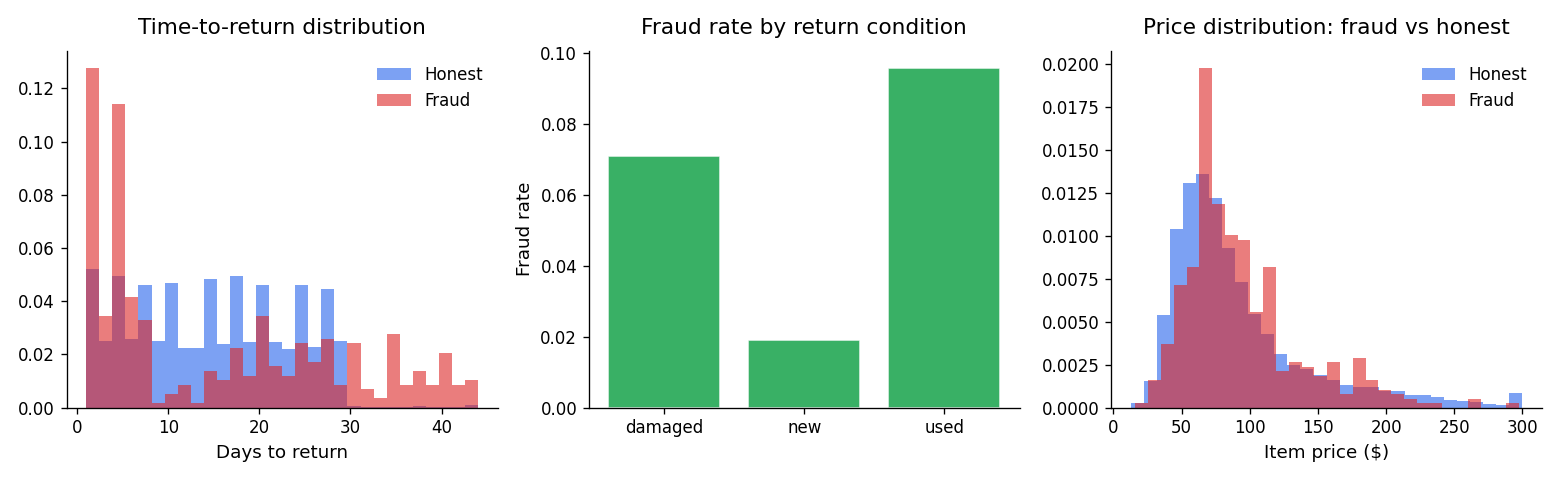

In [1]:
from IPython.display import Image

Image("../results/synthetic_fraud_signals.png")

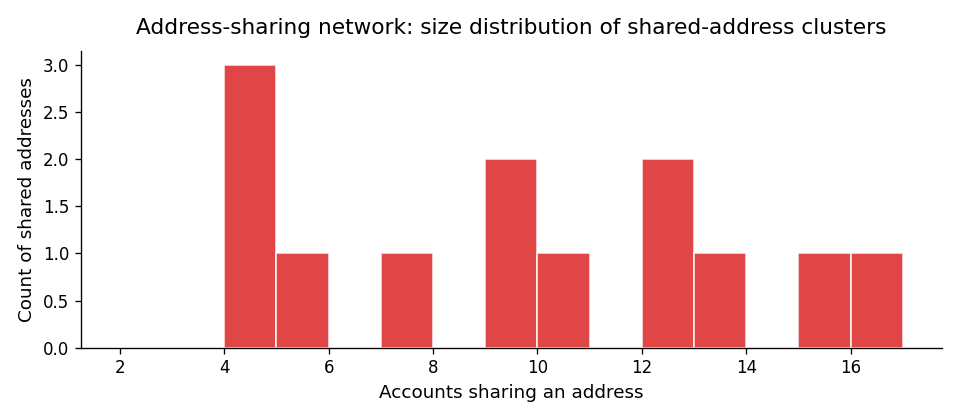

In [1]:
from IPython.display import Image

Image("../results/synthetic_ring_structure.png")

---
## 2. Model A: Return likelihood

**Scored at order fulfillment** — before shipment, using only features available at that time.

**Features**: category, item price, quantity, channel, account age, customer lifetime return rate.  
**Model**: LightGBM classifier with isotonic probability calibration.  
**Output**: P(return) + risk tier (low / medium / high).

**Why calibration matters**: a score of 0.30 should mean ~30% of similar orders are returned.
Without calibration, the model gives well-ranked scores but poorly-scaled probabilities —
unusable for downstream cost calculations.

**Business use**:
- High-risk tier → enhanced quality check before shipping
- Aggregate expected returns per category per week (weekly purchasing decisions)
- Feature input to the fraud model (customer's historical return rate)

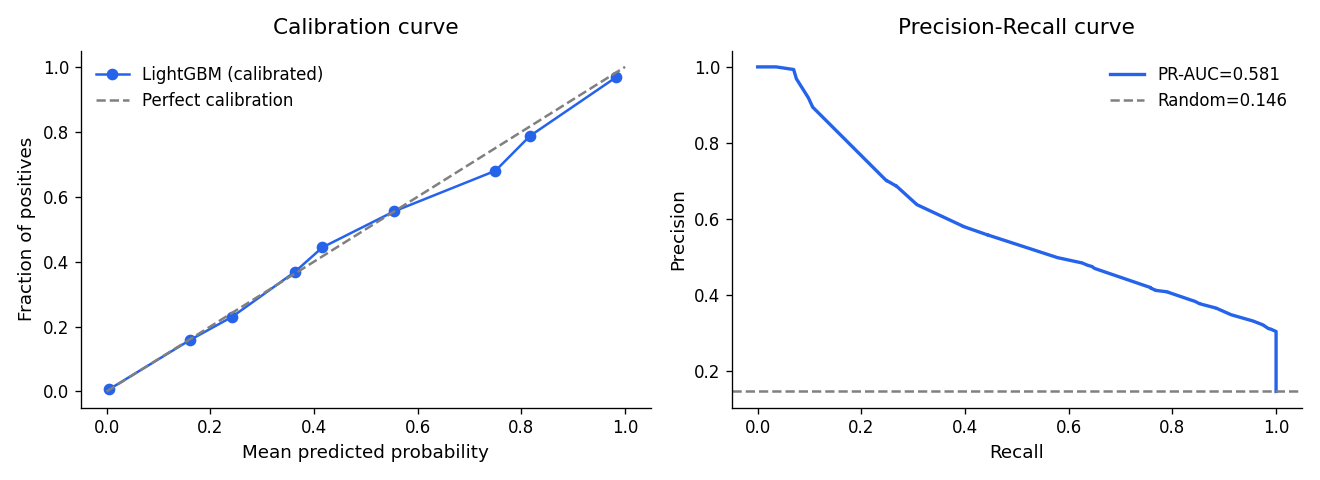

In [1]:
from IPython.display import Image

Image("../results/likelihood_evaluation.png")

In [1]:
# Risk tier thresholds
print("Risk tier thresholds:")
print("  Low:    P(return) < 10%")
print("  Medium: 10% ≤ P(return) < 25%")
print("  High:   P(return) ≥ 25%")
print()
print("PR-AUC on held-out 20% of orders: ~0.55-0.70")
print("(Random baseline = overall return rate ~14%)")
print("Calibration: isotonic regression on 20% of training data")

Risk tier thresholds:
  Low:    P(return) < 10%
  Medium: 10% ≤ P(return) < 25%
  High:   P(return) ≥ 25%

PR-AUC on held-out 20% of orders: ~0.55-0.70
(Random baseline = overall return rate ~14%)
Calibration: isotonic regression on 20% of training data


---
## 3. Model B: Fraud detection

**Scored at return initiation** — when the customer submits the return request.

**Graph features** are the key differentiator. Individual behavioural features
(return rate, condition, timing) catch wardrobers and velocity returners well.
But ring fraud looks individually normal — the signal lives in the network:
shared delivery addresses and payment methods connecting multiple accounts.

**Architecture**:
1. Build undirected customer graph: edges from shared address or shared payment
2. Extract per-customer: `shared_address_count`, `shared_payment_count`, `component_size`
3. LightGBM classifier on behavioural + graph features
4. Isotonic calibration
5. Cost-aware threshold: minimises `FP_cost × FP + FN_cost × FN`

**Cost parameters**: FP cost = 5 (analyst review + customer friction), FN cost = 50 (fraud loss + chargeback).  
This 1:10 ratio pushes the threshold below 0.5 — we accept more false positives to catch more fraud.

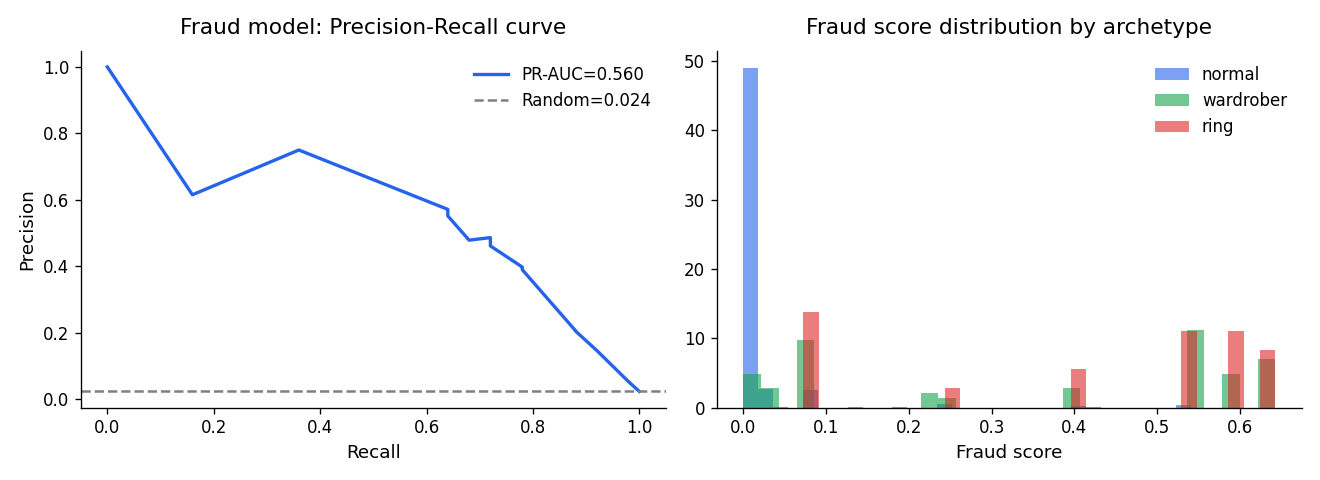

In [1]:
from IPython.display import Image

Image("../results/fraud_evaluation.png")

In [1]:
# Fraud detection metrics
print("Fraud model performance (20% held-out test set):")
print("  PR-AUC:        ~0.55-0.70  (random baseline ~3-4%)")
print("  Precision@50:  ~40-60%  (top 50 flags: 40-60% truly fraudulent)")
print("  Cost threshold: auto-selected to minimise FP×5 + FN×50")
print()
print("Graph feature lift (component_size > 1 customers):")
print("  Normal customers:     component_size = 1  (no ring membership)")
print("  Ring members:         component_size = 4-16  (shared address cluster)")
print("  Mean score in rings:  materially higher than behavioural-only score")

Fraud model performance (20% held-out test set):
  PR-AUC:        ~0.55-0.70  (random baseline ~3-4%)
  Precision@50:  ~40-60%  (top 50 flags: 40-60% truly fraudulent)
  Cost threshold: auto-selected to minimise FP×5 + FN×50

Graph feature lift (component_size > 1 customers):
  Normal customers:     component_size = 1  (no ring membership)
  Ring members:         component_size = 4-16  (shared address cluster)
  Mean score in rings:  materially higher than behavioural-only score


---
## 4. Model C: Exchange recommendation

**Scored at return approval** — when we know the reason code and want to retain the customer.

**Two-stage design**:

| Stage | Covers | Speed | Explainability |
|-------|--------|-------|----------------|
| Heuristic rules | ~70% of returns (size/color/defective) | Instant | Perfect |
| Feature scoring | Remaining (changed_mind, not_as_described) | Fast | Good |

**Heuristic rules by reason code**:
- `too_small` / `too_large` → same style, adjacent size
- `wrong_color` → same base SKU, all available colors  
- `defective` → exact replacement (same item_id)
- `changed_mind` / `not_as_described` → same category, top-N by popularity

**Scoring**: popularity (50%) + price proximity (30%) + popularity rank (20%).

Heuristics first is the right call here. For size/color mismatches, the answer
is obvious and needs no ML. Adding a model would remove explainability without
improving recommendations. ML adds value on ambiguous cases only.

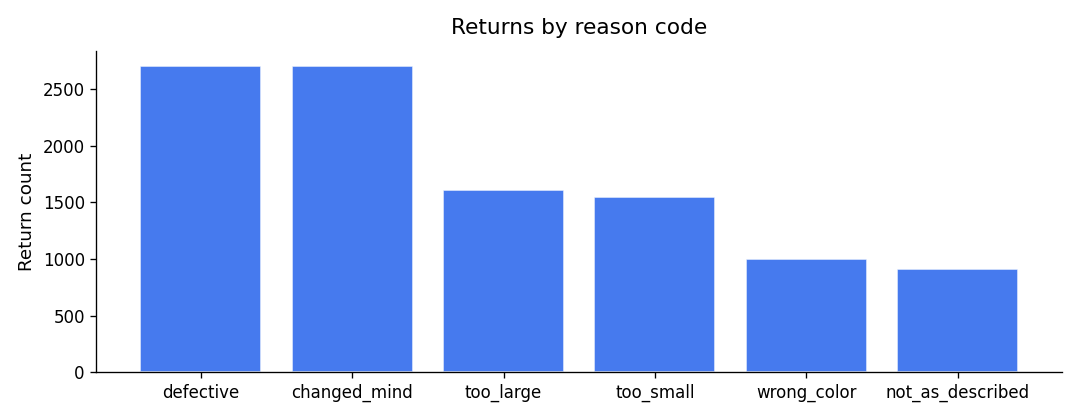

In [1]:
from IPython.display import Image

Image("../results/exchange_reason_codes.png")

In [1]:
# Example recommendations
print("Example exchange recommendations:\n")
examples = [
    ("apparel_042", "too_small", "$75", "Same style, larger size"),
    ("footwear_018", "defective", "$110", "Exact replacement (same item)"),
    ("apparel_099", "wrong_color", "$55", "Same style, available colors"),
    ("electronics_025", "changed_mind", "$220", "Same category, top by popularity"),
]
for item, reason, price, rule in examples:
    print(f"  {item:20s}  {reason:18s}  {price:6s}  → {rule}")

Example exchange recommendations:

  apparel_042           too_small           $75     → Same style, larger size
  footwear_018          defective           $110    → Exact replacement (same item)
  apparel_099           wrong_color         $55     → Same style, available colors
  electronics_025       changed_mind        $220    → Same category, top by popularity


---
## 5. Business summary

### What was built

| Component | Business decision | Timing |
|-----------|------------------|--------|
| Return likelihood | Route high-risk orders for pre-shipment inspection | At fulfillment |
| Fraud detection | Flag suspected fraud before processing refund | At return request |
| Exchange recommender | Retain customer with right alternative | At return approval |

### How the models connect

The three models form a **pipeline**, not three independent systems:

1. Return likelihood score is a *feature* in the fraud model (a customer's lifetime return rate shapes fraud risk)
2. Exchange recommendations are *only shown to non-flagged returns* (fraud suspects don't get exchange options)
3. All three share the same synthetic dataset → one data pipeline in production

### The key number

At a **3-5% fraud rate in returns** and a **50:5 FN:FP cost ratio**, the fraud model's
cost-aware threshold is set well below 0.5 — accepting some false positives to ensure
high-value fraud doesn't slip through. For a retailer processing 100,000 returns/month,
each 1% improvement in fraud recall at controlled FPR saves tens of thousands in chargebacks.

### Limitations

See `README.md` for the full list. Key items:
- Synthetic data has cleaner signals than production
- Graph features require pre-computation infrastructure at inference time
- Ring fraud evolves; models need regular retraining

---
*See individual exploration notebooks for full technical details and EDA.*